<a href="https://colab.research.google.com/github/hsultova/Softuni-AI-Integrations/blob/main/regular_exam_hsultova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [190]:
%pip install -q openai chromadb pypdf

In [303]:
import base64
import json

from pathlib import Path
from pprint import pprint
from typing import List, Literal

from pydantic import BaseModel, Field
from pypdf import PdfReader

from IPython.display import Audio, Image

from chromadb import PersistentClient
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction
from openai import OpenAI

from google.colab import userdata

# AI models and client initialization

In [304]:
OPENAI_TEXT_MODEL = "gpt-4.1-nano"
OPENAI_IMAGE_MODEL = "gpt-image-1-mini"
OPENAI_SPEECH_MODEL = "gpt-4o-mini-tts"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

In [305]:
openai_api_key = userdata.get('OpenAI_API_key')
openai_client = OpenAI(api_key=openai_api_key)

# Extract content from the pdf file

In [306]:
path_to_pdf = Path("/content/Recipe_collection.pdf")

if not path_to_pdf.exists():
  raise FileNotFoundError(f"The file {path_to_pdf} does not exist.")

pdf_reader = PdfReader(path_to_pdf)
print(f"Reading {path_to_pdf}")

Reading /content/Recipe_collection.pdf


In [307]:
text_fragments = [page.extract_text() for page in pdf_reader.pages]
text = '\n'.join(text_fragments)
print(f"Extracted {len(pdf_reader.pages)} pages from {path_to_pdf}")

Extracted 30 pages from /content/Recipe_collection.pdf


# Create ChromaDb collection

In [8]:
PATH_TO_CHROMA = "/content/db"
chroma_client = PersistentClient(path=PATH_TO_CHROMA)

In [308]:
chroma_collection = chroma_client.get_or_create_collection(
    name="recipe_collection",
    embedding_function=OpenAIEmbeddingFunction(
        api_key=openai_api_key,
        model_name=OPENAI_EMBEDDING_MODEL))

print(f"The chroma collection with name '{chroma_collection.name}' was created successfully.")

The chroma collection with name 'recipe_collection' was created successfully.


# Parse recipes

In [10]:
def parse_recipes(text):
    recipes = []

    # Find all positions of each keyword marker
    def find_all(text, keyword):
        positions = []
        start = 0
        while True:
            pos = text.find(keyword, start)
            if pos == -1:
                break
            positions.append(pos)
            start = pos + len(keyword)
        return positions

    ing_positions = find_all(text, "INGREDIENTS")
    prep_positions = find_all(text, "PREPARATION")
    gtk_positions = find_all(text, "GOOD TO KNOW")

    for i in range(len(ing_positions)):
        # --- HEADER: from previous GOOD TO KNOW to this INGREDIENTS ---
        header_start = gtk_positions[i - 1] + len("GOOD TO KNOW") if i > 0 else 0
        header = text[header_start:ing_positions[i]].strip()

        # Find recipe name: the line right before the origin line (which has ·)
        lines = [l.strip() for l in header.split("\n") if l.strip()]

        name = ""
        description = ""
        for j in range(len(lines) - 1):
            if "·" in lines[j + 1]:
                name = lines[j]
                description = " ".join(lines[j + 2:])
                break

        if not name:
            continue

        # --- INGREDIENTS: between INGREDIENTS and PREPARATION ---
        ingredients = text[ing_positions[i] + len("INGREDIENTS"):prep_positions[i]]
        ingredients = " ".join(ingredients.split())

        # --- PREPARATION: between PREPARATION and GOOD TO KNOW ---
        preparation = text[prep_positions[i] + len("PREPARATION"):gtk_positions[i]]
        preparation = " ".join(preparation.split())

        # --- FACT: from GOOD TO KNOW until next recipe starts ---
        fact_end = ing_positions[i + 1] if i + 1 < len(ing_positions) else len(text)
        fact_raw = text[gtk_positions[i] + len("GOOD TO KNOW"):fact_end].strip()

        # Trim off the next recipe's header that leaks into the fact
        fact_lines = []
        for line in fact_raw.split("\n"):
            line = line.strip()
            if not line:
                continue
            # Stop at next recipe's origin line (has ·)
            if "·" in line:
                if fact_lines:
                    fact_lines.pop()  # remove the recipe name that snuck in
                break
            # Stop at category headers like "02Soups & Salads"
            if len(line) >= 2 and line[0].isdigit() and line[1].isdigit():
                break
            fact_lines.append(line)

        fact = " ".join(" ".join(fact_lines).split())

        recipes.append({
            "name": name,
            "description": description,
            "ingredients": ingredients,
            "preparation": preparation,
            "fact": fact,
        })

    return recipes

In [309]:
def index_recipes(text: str):
    recipes = parse_recipes(text)

    chroma_collection.upsert(
        ids=[f"recipe_{i}" for i in range(len(recipes))],
        documents=[recipe["preparation"] for recipe in recipes],
        metadatas=[{
            "name": recipe["name"],
            "description": recipe["description"],
            "ingredients": recipe["ingredients"],
            "fact": recipe["fact"],
        } for recipe in recipes],
    )

    return recipes

In [138]:
def print_recipes(recipes: []):
  for recipe in recipes:
    print()
    for key, value in recipe.items():
      print(f"{key}: {value}")

In [310]:
indexed = index_recipes(text)
print(f"Indexed {len(indexed)} recipes successfully:")
print_recipes(indexed)

Indexed 24 recipes successfully:

name: Bruschetta al Pomodoro
description: Grilled bread rubbed with garlic and piled with ripe tomatoes, basil and olive oil — the purest expression of a summer harvest.
ingredients: 8 slices country bread 4 ripe tomatoes 2 garlic cloves 1 handful fresh basil 3 tbsp olive oil ½ tsp salt
preparation: 1. Dice ripe tomatoes, toss with salt and drain 10 minutes. 2. Grill thick slices of country bread until charred at the edges. 3. Rub each slice with a cut garlic clove. 4. Fold torn basil and olive oil into the tomatoes, then spoon on top.
fact: The name comes from bruscare, Roman dialect for "to roast over coals." Peasants used it to test the year's fresh-pressed olive oil.

name: Hummus bi Tahini
description: A silken purée of chickpeas and sesame tahini, sharpened with lemon and garlic and pooled with green olive oil.
ingredients: 250 g dried chickpeas 120 g tahini 2 lemons 2 garlic cloves 1 tsp ground cumin 4 tbsp olive oil ½ tsp baking soda 1 tsp salt

# Tools implementation

In [320]:
class Recipe(BaseModel):
  name: str
  description: str
  ingredients: str
  preparation: str
  facts: str

In [321]:
class LookupRecipeRequest(BaseModel):
    """
    Searches the recipe catalog using semantic similarity to find recipes
    matching the user's request. Use this tool when a user asks about
    recipes, recipe description, preparation steps, ingredients, or recipe facts.
    Returns the top matching recipes.
    """
    query: str = Field(description="A natural language search query describing the desired reipe, desctiption, ingredients, preparation steps or recipe intresting fact and country. For example, 'Mochi', 'baked cheesecake', 'All turkey recipes'")
    top_n: int = Field(description="Maximum number of matching recipes to return. Use a value between 1 and 20. Use 5 when the user does not say how many they want.")

class GenerateImageRequest(BaseModel):
    """Generate an image from a text description of the finished dish."""

    question: str = Field(description="The original question that is asked")
    answer: str = Field(description="The answer that is got")


In [322]:
MAX_RESULTS = 20

def lookup_recipe(req: LookupRecipeRequest) -> List[Recipe]:
    n_results = max(1, min(req.top_n, MAX_RESULTS))

    lookup_result = chroma_collection.query(
        query_texts=[req.query],
        n_results=n_results,
        include=["metadatas", "documents"]
    )

    results_count = len(lookup_result["ids"][0])

    return [Recipe(
        name=lookup_result["metadatas"][0][i]["name"],
        description=lookup_result["metadatas"][0][i]["description"],
        ingredients=lookup_result["metadatas"][0][i]["ingredients"],
        preparation=lookup_result["documents"][0][i],
        facts=lookup_result["metadatas"][0][i]["fact"],
    ) for i in range(results_count)]

In [333]:
lookup_recipe_tool_schema = LookupRecipeRequest.model_json_schema()
tools = [
    {
        "type": "function",
        "name": "lookup_recipe",
        "description": lookup_recipe_tool_schema["description"],
        "parameters": {
            "type": "object",
            "properties": lookup_recipe_tool_schema["properties"],
            "required": list(lookup_recipe_tool_schema["properties"].keys()),
            "additionalProperties": False
        },
        "strict": True
    }
]

tool_call_handlers = {
    "lookup_recipe": lambda args: [c.model_dump() for c in lookup_recipe(LookupRecipeRequest(**args))]
}

In [323]:
# def build_tool(name: str, model: type[BaseModel]) -> dict:
#     schema = model.model_json_schema()
#     parameters = {
#         "type": "object",
#         "properties": schema["properties"],
#         "required": list(schema["properties"]),
#         "additionalProperties": False,
#     }
#     # Nested models land in $defs and are referenced with $ref — carry them over.
#     if "$defs" in schema:
#         parameters["$defs"] = schema["$defs"]

#     return {
#         "type": "function",
#         "name": name,
#         "description": schema["description"],
#         "parameters": parameters,
#         "strict": True,
#     }

In [324]:
# lookup_recipe_tool_schema = LookupRecipeRequest.model_json_schema()

# tool_call_handlers = {
#     "lookup_recipe": (LookupRecipeRequest, lookup_recipe),
# }
# tools = [build_tool(name, model) for name, (model, _) in tool_call_handlers.items()]

In [325]:
# def call_tool(name: str, arguments: str) -> List[dict]:
#   """Dispatch one tool call from the model and return JSON-safe content blocks."""
#   if name not in tool_call_handlers:
#       raise ValueError(f"Unknown tool: {name!r}")

#   print(f"Loading {name} tool....")
#   model, fn = tool_call_handlers[name]
#   # model_validate_json parses and validates the raw arguments string in one step.
#   result = fn(model.model_validate_json(arguments))
#   return [block.model_dump() for block in result]

In [334]:
# def execute_tools(response) -> List[dict]:
#   outputs = []

#   for item in response.output:
#       if item.type != "function_call":
#           continue

#       output = call_tool(item.name, item.arguments)
#       outputs.append({
#           "type": "function_call_output",
#           "call_id": item.call_id,
#           "output": json.dumps(output, ensure_ascii=False),
#       })

#   return outputs

def execute_tools(response):
    tool_calls = [item for item in response.output if item.type == "function_call"]

    result = []
    for tool_call in tool_calls:
        args = json.loads(tool_call.arguments)
        if tool_call.name not in tool_call_handlers:
            raise Exception("Unknown tool!")

        output = tool_call_handlers[tool_call.name](args)
        result.append({
            "type": "function_call_output",
            "call_id": tool_call.call_id,
            "output": json.dumps(output)
        })

    return result

In [335]:
class MediaResult(BaseModel):
    kind: Literal["image", "speech"]
    path: str
    note: str

In [328]:
PATH_TO_IMAGE = Path("/content/last_answer.png")

def generate_image(question: str, answer: str) -> List[MediaResult]:
  image_system_prompt = f"""This is the question I asked: \"{question}\".
  This is the answer I got: \"{answer}\"

  Create a highly photorealistic image that helps visualize the answer by showing a realistic scene. Use only description of the recipe, ignore ingredients, if not explicitly specified.
  Generate the image based ONLY on the provided context - do not refer to your built-in knowledge.
  """
  generated_image = openai_client.images.generate(
      model=OPENAI_IMAGE_MODEL,
      prompt=image_system_prompt,
      size="1024x1024",
      quality="low",
      output_format="png"
      )
  print("Generating image...")

  for image in generated_image.data:
      image_bytes = base64.b64decode(image.b64_json)
      PATH_TO_IMAGE.write_bytes(image_bytes)
      display(Image(data=image_bytes, format="png"))
  # image_bytes = base64.b64decode(response.data[0].b64_json)
  # PATH_TO_IMAGE.write_bytes(image_bytes)
  # display(Image(data=image_bytes, format="png"))

  return [MediaResult(
        kind="image",
        path=str(PATH_TO_IMAGE),
        note="The image was generated and shown to the user.",
    )]

In [329]:
PATH_TO_AUDIO = Path("/content/last_answer.mp3")

def generate_speech(question: str, answer: str, voice: Literal["overhead", "table_level", "close_up"]) -> List[MediaResult]:
  speech_system_prompt = f"""This is the question I asked: \"{question}\".
  This is the answer I got: \"{answer}\"
  Generate speech based ONLY on the provided context from the answer I got - do not refer to your built-in knowledge.
  """
  response = openai_client.audio.speech.create(
            model=OPENAI_SPEECH_MODEL,
            input=speech_system_prompt,
            voice=voice
        )

  response.write_to_file(PATH_TO_AUDIO)
  display(Audio(str(PATH_TO_AUDIO)))

  print("Generating speech...")

  return [MediaResult(
        kind="speech",
        path=str(PATH_TO_AUDIO),
        note="The audio was generated and played for the user.",
    )]

# Retrieve information

In [336]:
system_prompt = (
    "Analyze all recipes and help the user when looking for recipes or related "
    "recipe data. Use the \"lookup_recipe\" tool whenever a user is asking for a "
    "recipe. Answer using only the recipes returned by the tool, and display the "
    "whole recipe matching the user description."
)

def retrieve_information(prompt: str) -> list:
  conversation = [
    { "role": "developer", "content": system_prompt },
    { "role": "user", "content": prompt }
  ]

  response = openai_client.responses.create(
    model=OPENAI_TEXT_MODEL,
    input=conversation,
    tools=tools
  )
  tool_outputs = execute_tools(response)
  if not tool_outputs:
    return response.output_text

  conversation += response.output
  conversation += tool_outputs

  return tool_outputs[0]["output"]

# Ask AI function

In [338]:
class IntermediateResponse(BaseModel):
  question: str
  format: Literal['text', 'image', 'speech']

system_prompt = """
Extract the user's core question about a recipe and the desired response format.
Do not ask follow-up questions, just extract the user prompt.
The format must be one of: text, image, speech.
If no format is mentioned, or in case of uncertainty, default to text.
If the format is 'image', phrase the question so it invites a descriptive answer
that can be used to generate an interesting and visually engaging image.
If the prompt mentions reading aloud or audio, the format is speech.
If the prompt is not detailed or you do not understand it, just repeat it.
"""

In [349]:
def ask_ai(question: str):

  intermediate_response = openai_client.responses.parse(
        model=OPENAI_TEXT_MODEL,
        input=[
            {"role": "developer", "content": system_prompt},
            {"role": "user", "content": question},
        ],
        text_format=IntermediateResponse
    )

  parsed = intermediate_response.output_parsed
  print("Intermediate response:")
  print(intermediate_response.output_parsed)

  answer = retrieve_information(parsed.question)

  if parsed.format == "image":
    generate_image(question=parsed.question, answer=answer)
  elif parsed.format == "speech":
    generate_speech(question=parsed.question, answer=answer, voice="nova")

  return answer
  # final_response = openai_client.responses.parse(
  #       model=OPENAI_TEXT_MODEL,
  #       input=final_system_promp,
  #       tools = tools
  #   )
  # tool_call_results = execute_tools(final_response)
  # conversation.extend(tool_call_results)

  # if intermediate_response.output_parsed.format == 'image':
  #     answer_image = generate_image(question, answer)
  #     for image in answer_image.data:
  #       image_bytes = base64.b64decode(image.b64_json)
  #       display(Image(data=image_bytes, format="png"))
  #       return answer_image

  # elif intermediate_response.output_parsed.format == 'speech':
  #      answer_speech = generate_speech(answer[0]["output"])
  #      path_to_answer = Path("/content/last_answer.mp3")
  #      answer_speech.write_to_file(path_to_answer)
  #      display(Audio(path_to_answer))
  #      return answer_speech


# Test cases

In [350]:
print_recipes(json.loads(ask_ai("Give me 5 recipes with chicken.")))

Intermediate response:
question='Can you provide 5 chicken recipes?' format='text'

name: Butter Chicken (Murgh Makhani)
description: Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.
ingredients: 800 g chicken 150 g yoghurt 400 g tomato 50 g cashews 60 g butter 150 ml cream 2 tbsp garam masala 1 tbsp kasuri methi
preparation: 1. Grill yoghurt-marinated chicken until lightly charred. 2. Simmer tomato with cashew, butter, cream and spices. 3. Blend the sauce smooth. 4. Add the chicken and finish with a knob of butter.
facts: It was invented in the 1950s at Delhi's Moti Mahal to use up unsold tandoori chicken — the tomato-butter gravy kept the meat from drying out.

name: Paella Valenciana
description: Saffron rice cooked flat and wide over fire, prized for the crisp socarrat at the bottom.
ingredients: 400 g bomba rice 500 g chicken or rabbit 150 g green beans 1 tomato & onion sofrito 1 pinch saffron 1 l stock 4 tbsp olive oil
preparation: 1. Sear chicken, rabbi

Intermediate response:
question='Please provide a detailed description of a soup recipe that can be used to create an engaging and visually appealing image.' format='image'


name: Minestrone
description: A thick, seasonal vegetable and bean soup bound with a little pasta — different in every kitchen.
ingredients: 1 onion 2 carrots 2 celery stalks 300 g seasonal vegetables 400 g cannellini beans 400 g tomato 1.5 l stock 100 g small pasta 40 g Parmesan
preparation: 1. Sweat a soffritto of onion, carrot and celery in olive oil. 2. Add seasonal vegetables, beans, tomato and stock. 3. Simmer until everything is tender. 4. Add small pasta near the end; finish with Parmesan.
facts: The name simply means "big soup." There's no fixed recipe — it was built from whatever the garden and larder offered that week. Greek Village Salad (Horiatiki) Greece Chunky tomato, cucumber, pepper and onion with olives and a slab of feta — no lettuce in sight.
Generating image...


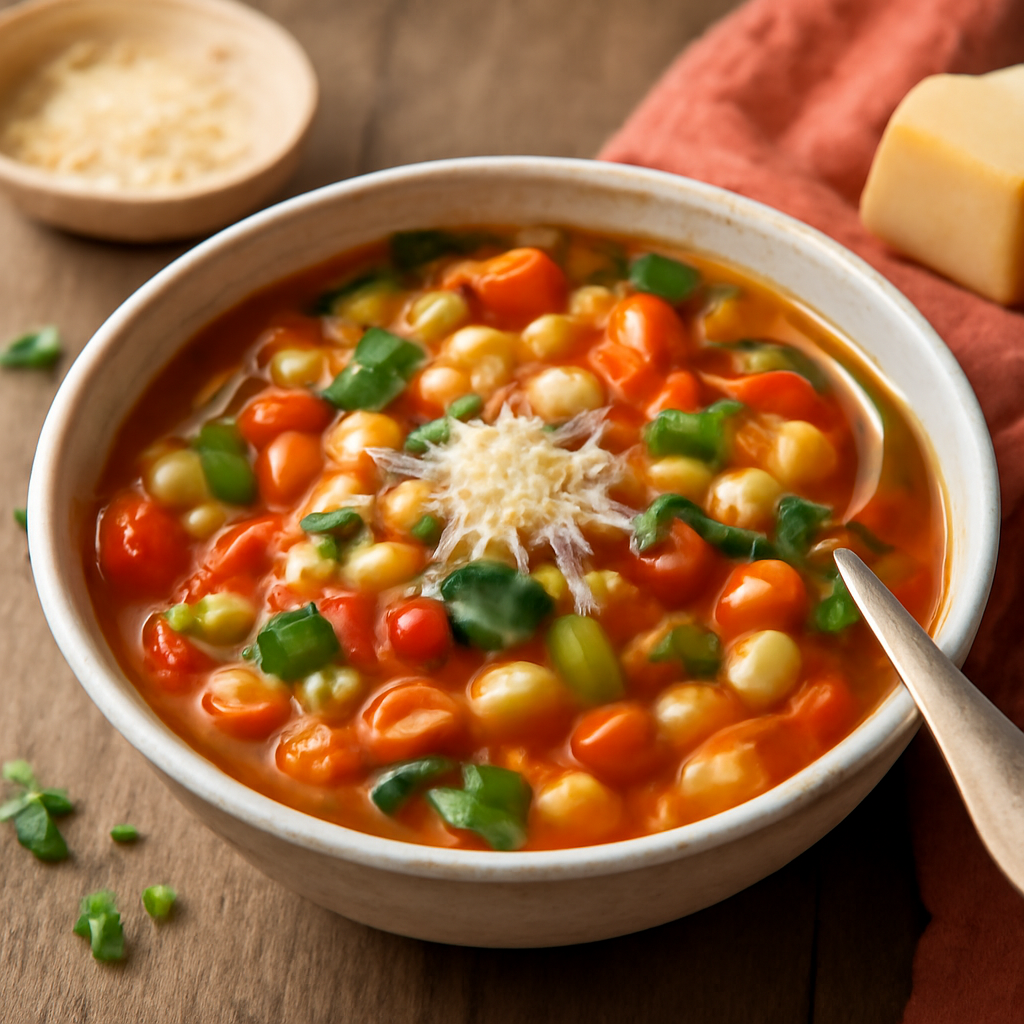

In [342]:
soup_response = ask_ai("I want a recipe for a soup as image.")

Intermediate response:
question='Generate an image for a Turkish dessert similar to Baklava, showcasing its layers and texture.' format='image'


name: Baklava
description: Layers of paper-thin filo and chopped nuts drenched in spiced syrup or honey.
ingredients: 400 g filo pastry 300 g walnuts or pistachios 200 g butter 200 g sugar 150 g honey 1 lemon 1 tsp cinnamon
preparation: 1. Brush filo sheets with butter, layering with nuts between. 2. Cut into diamonds before baking. 3. Bake until deeply golden and crisp. 4. Pour cool syrup over the hot pastry and let it soak.
facts: Perfected in the kitchens of Istanbul's Topkapı Palace. Pouring cool syrup on hot pastry (or vice versa) is what keeps it crisp, not soggy. Churros Spain Ridged sticks of fried dough rolled in sugar, for dunking in thick hot chocolate.
Generating image...


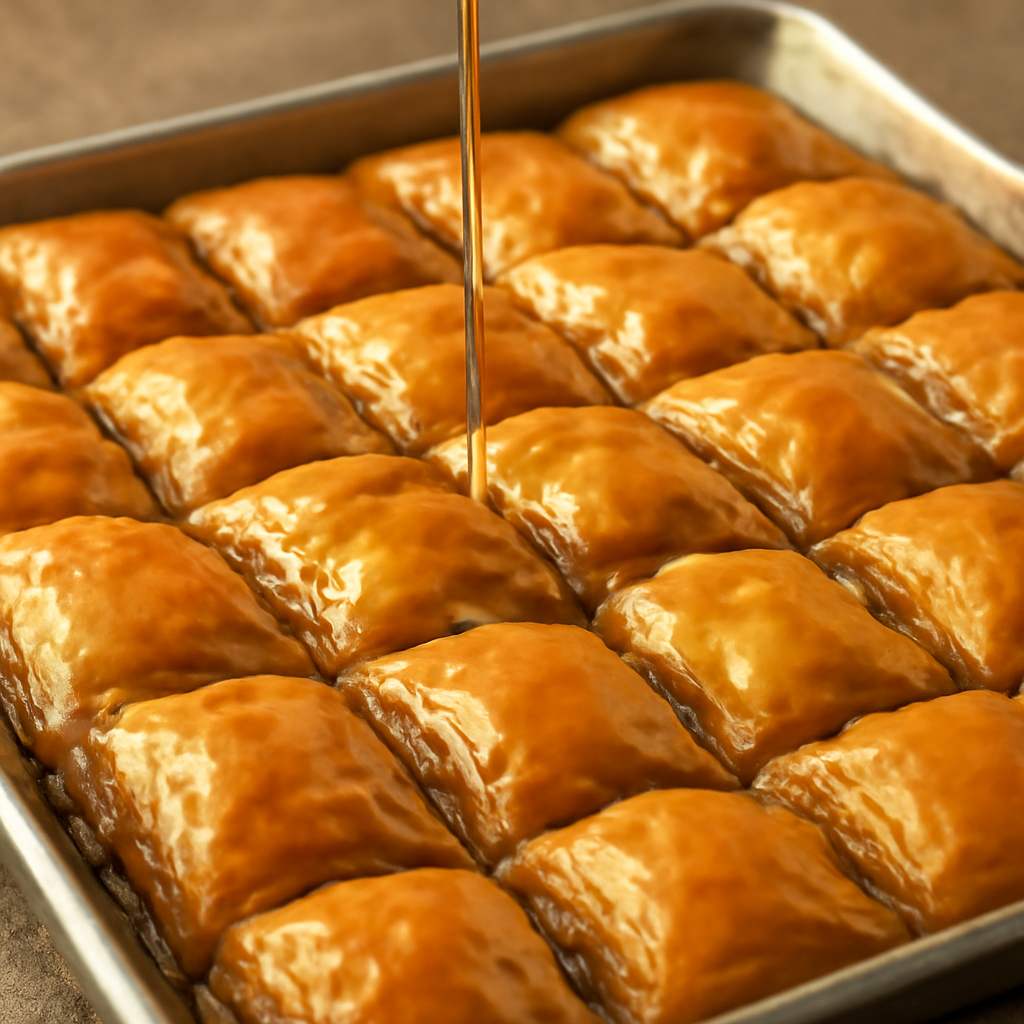

'[{"name": "Baklava", "description": "Layers of paper-thin filo and chopped nuts drenched in spiced syrup or honey.", "ingredients": "400 g filo pastry 300 g walnuts or pistachios 200 g butter 200 g sugar 150 g honey 1 lemon 1 tsp cinnamon", "preparation": "1. Brush filo sheets with butter, layering with nuts between. 2. Cut into diamonds before baking. 3. Bake until deeply golden and crisp. 4. Pour cool syrup over the hot pastry and let it soak.", "facts": "Perfected in the kitchens of Istanbul\'s Topkapı Palace. Pouring cool syrup on hot pastry (or vice versa) is what keeps it crisp, not soggy. Churros Spain Ridged sticks of fried dough rolled in sugar, for dunking in thick hot chocolate."}]'

In [297]:
ask_ai("Generate image for a dessert that is from Turkey - Baklava or something similar.")

Intermediate response:
question='Can you provide an image showing two different dishes with chicken placed side by side for comparison?' format='image'


name: Butter Chicken (Murgh Makhani)
description: Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.
ingredients: 800 g chicken 150 g yoghurt 400 g tomato 50 g cashews 60 g butter 150 ml cream 2 tbsp garam masala 1 tbsp kasuri methi
preparation: 1. Grill yoghurt-marinated chicken until lightly charred. 2. Simmer tomato with cashew, butter, cream and spices. 3. Blend the sauce smooth. 4. Add the chicken and finish with a knob of butter.
facts: It was invented in the 1950s at Delhi's Moti Mahal to use up unsold tandoori chicken — the tomato-butter gravy kept the meat from drying out.
Generating image...


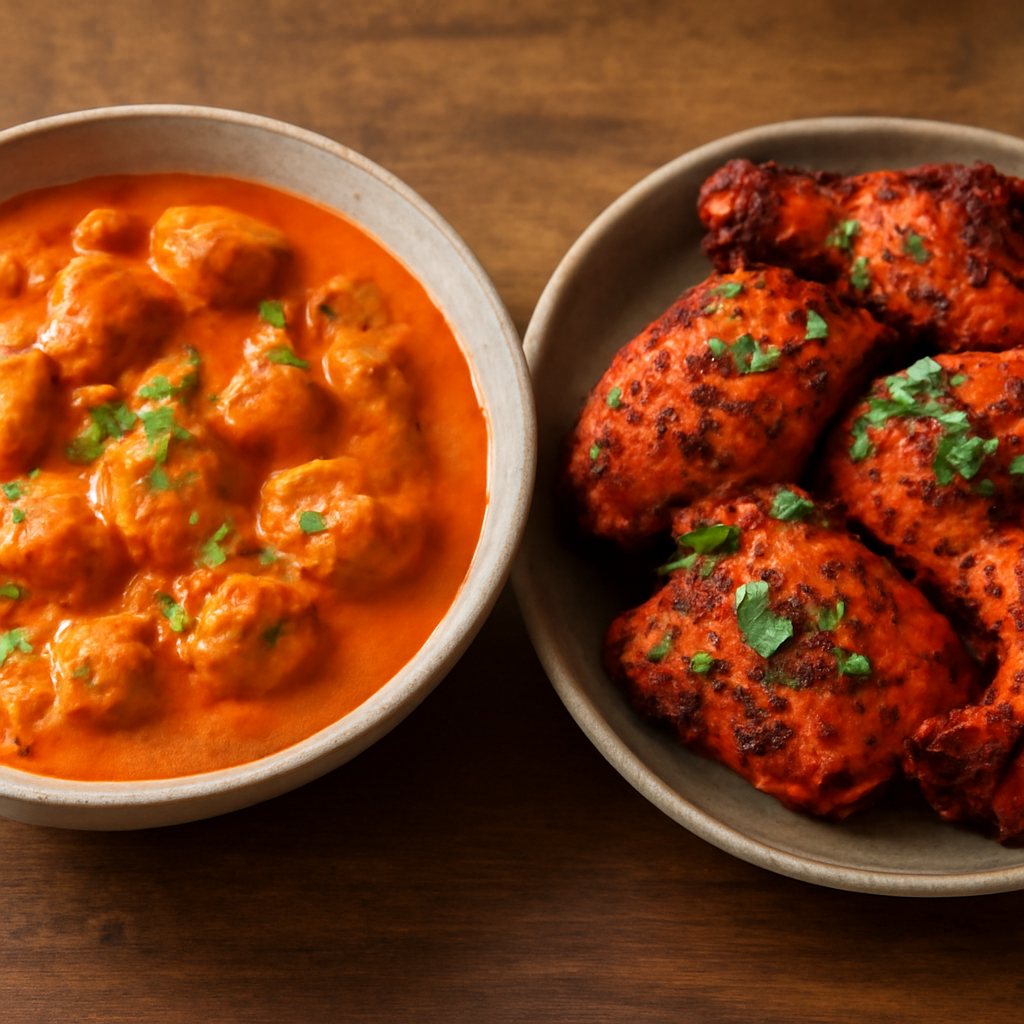

'[{"name": "Butter Chicken (Murgh Makhani)", "description": "Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.", "ingredients": "800 g chicken 150 g yoghurt 400 g tomato 50 g cashews 60 g butter 150 ml cream 2 tbsp garam masala 1 tbsp kasuri methi", "preparation": "1. Grill yoghurt-marinated chicken until lightly charred. 2. Simmer tomato with cashew, butter, cream and spices. 3. Blend the sauce smooth. 4. Add the chicken and finish with a knob of butter.", "facts": "It was invented in the 1950s at Delhi\'s Moti Mahal to use up unsold tandoori chicken \\u2014 the tomato-butter gravy kept the meat from drying out."}]'

In [343]:
ask_ai("I want an image of 2 dishes with chicken. The result should be in one picture as comparison. ")

Intermediate response:
question='Describe a visually appealing image of Spaghetti alla Carbonara.' format='image'
Generating image...


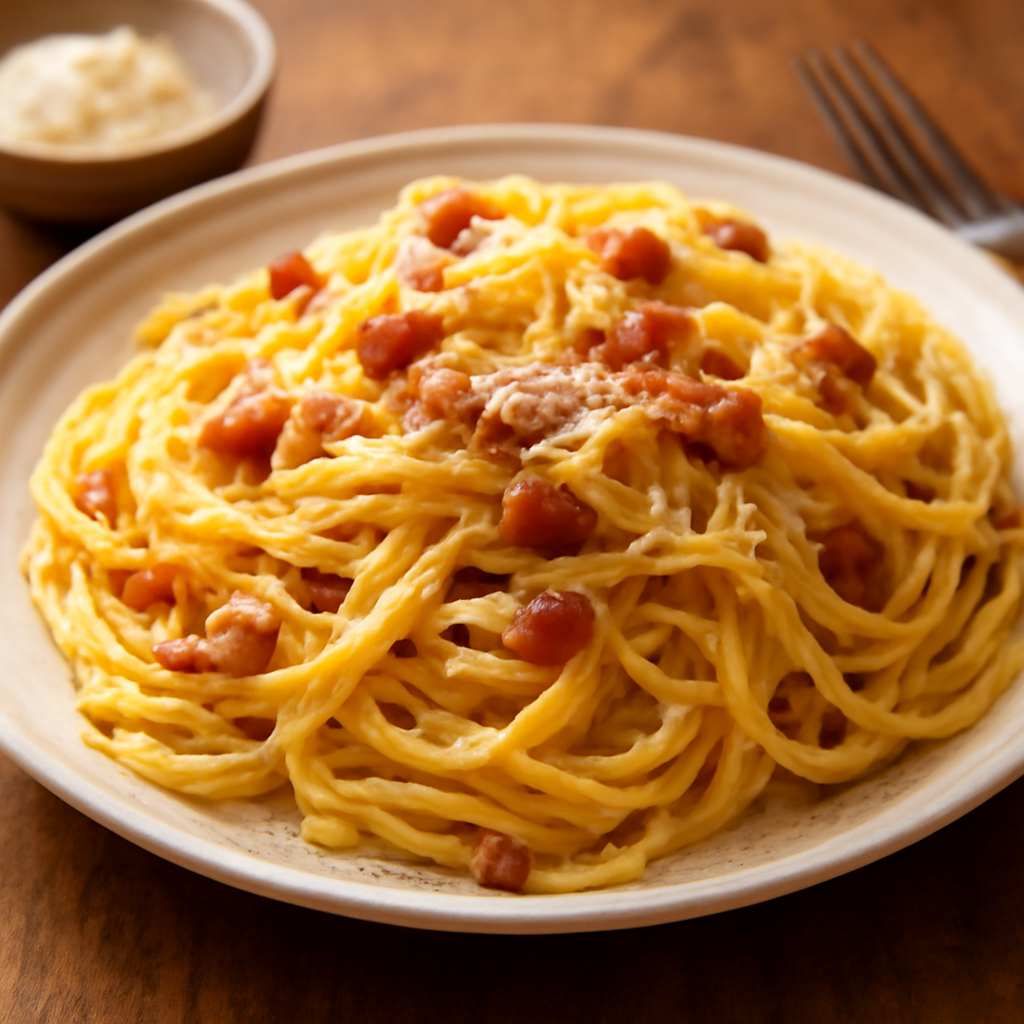

'Describe a visually appealing image of Spaghetti alla Carbonara.'

In [351]:
ask_ai("Spaghetti alla Carbonara image")

In [298]:
ask_ai("Read me one recipe for meal with chicken")

Intermediate response:
question='Can you provide me with a recipe for a chicken meal?' format='text'


name: Butter Chicken (Murgh Makhani)
description: Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.
ingredients: 800 g chicken 150 g yoghurt 400 g tomato 50 g cashews 60 g butter 150 ml cream 2 tbsp garam masala 1 tbsp kasuri methi
preparation: 1. Grill yoghurt-marinated chicken until lightly charred. 2. Simmer tomato with cashew, butter, cream and spices. 3. Blend the sauce smooth. 4. Add the chicken and finish with a knob of butter.
facts: It was invented in the 1950s at Delhi's Moti Mahal to use up unsold tandoori chicken — the tomato-butter gravy kept the meat from drying out.


'[{"name": "Butter Chicken (Murgh Makhani)", "description": "Tandoori chicken finished in a velvety tomato-butter sauce, mild and rich.", "ingredients": "800 g chicken 150 g yoghurt 400 g tomato 50 g cashews 60 g butter 150 ml cream 2 tbsp garam masala 1 tbsp kasuri methi", "preparation": "1. Grill yoghurt-marinated chicken until lightly charred. 2. Simmer tomato with cashew, butter, cream and spices. 3. Blend the sauce smooth. 4. Add the chicken and finish with a knob of butter.", "facts": "It was invented in the 1950s at Delhi\'s Moti Mahal to use up unsold tandoori chicken — the tomato-butter gravy kept the meat from drying out."}]'

In [299]:
ask_ai("Read me ingrediants (with pleasant speech) of the recipe of Spaghetti alla Carbonara")

Intermediate response:
question='Read me ingredients (with pleasant speech) of the recipe of Spaghetti alla Carbonara.' format='speech'


name: Spaghetti alla Carbonara
description: Pasta bound in a glossy sauce of egg, Pecorino and guanciale — no cream, ever.
ingredients: 400 g spaghetti 150 g guanciale 3 eggs + 1 yolk 70 g Pecorino Romano 1 tsp black pepper
preparation: 1. Crisp diced guanciale in its own fat. 2. Whisk eggs with grated Pecorino and lots of black pepper. 3. Toss hot drained pasta with the pork, off the heat. 4. Add the egg mix with pasta water, tossing to a cream.
facts: The "cream" is only egg and cheese emulsified with starchy water. Roman cooks insist the pan comes off the heat or you get scrambled eggs. Goulash (Gulyás) Hungary A paprika-rich beef and onion stew, somewhere between a soup and a braise.


Generating speech...


'[{"name": "Spaghetti alla Carbonara", "description": "Pasta bound in a glossy sauce of egg, Pecorino and guanciale — no cream, ever.", "ingredients": "400 g spaghetti 150 g guanciale 3 eggs + 1 yolk 70 g Pecorino Romano 1 tsp black pepper", "preparation": "1. Crisp diced guanciale in its own fat. 2. Whisk eggs with grated Pecorino and lots of black pepper. 3. Toss hot drained pasta with the pork, off the heat. 4. Add the egg mix with pasta water, tossing to a cream.", "facts": "The \\"cream\\" is only egg and cheese emulsified with starchy water. Roman cooks insist the pan comes off the heat or you get scrambled eggs. Goulash (Gulyás) Hungary A paprika-rich beef and onion stew, somewhere between a soup and a braise."}]'

In [352]:
ask_ai("Recipe of Spaghetti alla Carbonara - speech")

Intermediate response:
question='Please provide the recipe for Spaghetti alla Carbonara in a speech format.' format='speech'


Generating speech...


'You would like me to provide the recipe for Spaghetti alla Carbonara in a speech format.'